<a href="https://colab.research.google.com/github/sofiasanvi/PRO1/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv
import matplotlib.pyplot as plt
import statistics
import numpy as np

In the code below, we import the data. The dataset contains different samples with their corresponding OTUs and the abundance of each OTU. From this data, we calculate how many different OTUs are present in each sample. If the abundance of an OTU is 0, it is not counted as present. The total number of OTUs for each sample is then stored in a dictionary. Finally, the values from the dictionary are plotted in a histogram to visualize the distribution of OTU richness across the samples.


{'TARA_N000000077': 938, 'TARA_A100001640': 3857, 'TARA_N000000835': 1776, 'TARA_N000000827': 6465, 'TARA_N000000839': 2762, 'TARA_N000000845': 1126, 'TARA_N000000837': 4085, 'TARA_N000000829': 7602, 'TARA_N000000833': 8045, 'TARA_N000000841': 2185, 'TARA_A100000402': 938, 'TARA_A100001646': 1660, 'TARA_A100000394': 2056, 'TARA_A100000393': 5924, 'TARA_A100000400': 2114, 'TARA_E500000200': 1455, 'TARA_A100000398': 1898, 'TARA_A100000396': 7791, 'TARA_E500000196': 3273, 'TARA_N000001664': 1520, 'TARA_N000001654': 3565, 'TARA_N000001646': 5254, 'TARA_N000001650': 5843, 'TARA_N000001658': 3505, 'TARA_N000001656': 3007, 'TARA_N000001648': 3713, 'TARA_N000001652': 4268, 'TARA_N000001660': 1510, 'TARA_A100000546': 934, 'TARA_A100000553': 3573, 'TARA_A100000551': 6900, 'TARA_A100001333': 6370, 'TARA_A100000548': 3769, 'TARA_A100000554': 2812, 'TARA_A100000558': 521, 'TARA_A100000559': 6969, 'TARA_A100000556': 1414, 'TARA_A100000594': 974, 'TARA_A100000598': 2985, 'TARA_A100000595': 5438, 'TAR

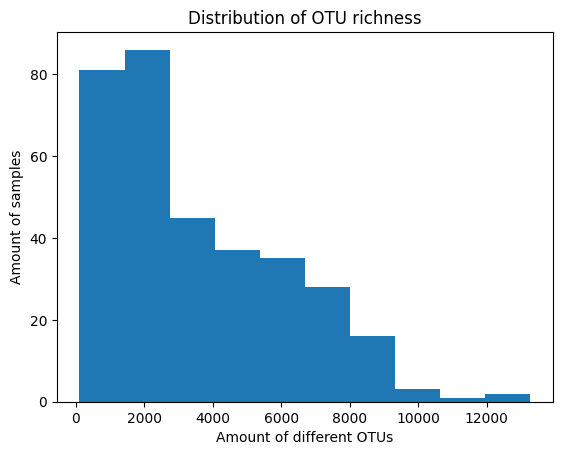

In [ ]:
filename = "Database_W5_OTU_occurences.tsv"

with open(filename, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file, delimiter="\t")

    sample_columns = []

    for column in reader.fieldnames:
        if column.startswith("TARA_"):
            sample_columns.append(column)

    richness = {}

    for sample in sample_columns:
        richness[sample] = 0

    for row in reader:
        for sample in sample_columns:
            count = float(row[sample])

            if count > 0:
                richness[sample] += 1

print(richness)
print("Mean richness:", statistics.mean(richness.values()))
print("Variance in richness:", statistics.variance(richness.values()))
plt.hist(richness.values())
plt.title('Distribution of OTU richness')
plt.xlabel('Number of OTUs per sample')
plt.ylabel('Number of samples')
plt.show()

To fit a model to our data, we selected a negative binomial distribution. We first considered a Poisson distribution because the values we are working with are count data. However, a Poisson distribution assumes that the expected value and the variance are approximately equal, \(E[X] = Var(X)\). In our data, the variance was clearly larger than the mean, which indicates overdispersion.

One possible reason for this large variation is that the samples were collected from different ocean environments, where factors such as light, pH, depth, and ion concentrations may differ. Because the negative binomial distribution can account for greater variation than the Poisson distribution, we considered it a more suitable model for our data.

The negative binomial distribution has two parameters that control the mean and the amount of variation in the distribution. In the following code, we estimate these parameters using the mean and variance of our observed data and use them to fit a negative binomial model.


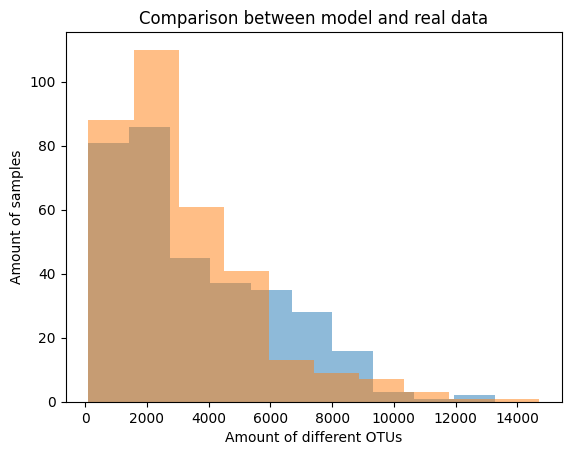

In [ ]:
values = np.array(list(richness.values()))

mean = np.mean(values)
variance = np.var(values, ddof=1)

n = mean**2 / (variance - mean)
p = n / (n + mean)

random_nb = np.random.negative_binomial(n, p, size=len(values))

plt.hist(values, alpha=0.5, label="Observed")
plt.hist(random_nb, alpha=0.5, label="Negative binomial")
plt.title('Comparison between model and real data')
plt.xlabel('Number of OTUs per sample')
plt.ylabel('Number of samples')
plt.show()